In [113]:
import numpy as np
import pandas as pd

import seaborn as sns

In [114]:
df = pd.read_csv("car_fuel_efficiency.csv")
df.columns

Index(['engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'model_year', 'origin', 'fuel_type', 'drivetrain',
       'num_doors', 'fuel_efficiency_mpg'],
      dtype='str')

In [115]:
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

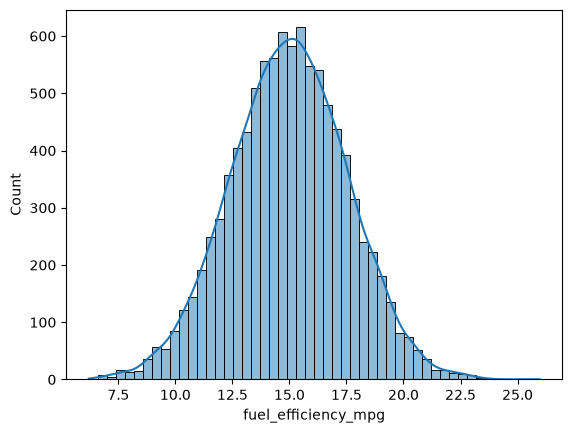

In [116]:
# Plot the distribution of the target variable
sns.histplot(df["fuel_efficiency_mpg"], bins=50, kde=True)

In [117]:
df.describe()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,num_doors,fuel_efficiency_mpg
count,9704.000000,9222.000000,8996.000000,9704.000000,8774.000000,9704.000000,9202.000000,9704.000000
mean,199.708368,3.962481,149.657292,3001.280993,15.021928,2011.484027,-0.006412,14.985243
std,49.455319,1.999323,29.879555,497.894860,2.510339,6.659808,1.048162,2.556468
min,10.000000,0.000000,37.000000,952.681761,6.000000,2000.000000,-4.000000,6.200971
25%,170.000000,3.000000,130.000000,2666.248985,13.300000,2006.000000,-1.000000,13.267459
50%,200.000000,4.000000,149.000000,2993.226296,15.000000,2012.000000,0.000000,15.006037
75%,230.000000,5.000000,170.000000,3334.957039,16.700000,2017.000000,1.000000,16.707965
max,380.000000,13.000000,271.000000,4739.077089,24.300000,2023.000000,4.000000,25.967222


In [118]:
# We will use some of the features to predict the target variable. Let's select the following features:
columns = [
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year',
    'fuel_efficiency_mpg'
]

df = df[columns]
df.describe()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
count,9704.000000,8996.000000,9704.000000,9704.000000,9704.000000
mean,199.708368,149.657292,3001.280993,2011.484027,14.985243
std,49.455319,29.879555,497.894860,6.659808,2.556468
min,10.000000,37.000000,952.681761,2000.000000,6.200971
25%,170.000000,130.000000,2666.248985,2006.000000,13.267459
50%,200.000000,149.000000,2993.226296,2012.000000,15.006037
75%,230.000000,170.000000,3334.957039,2017.000000,16.707965
max,380.000000,271.000000,4739.077089,2023.000000,25.967222


In [119]:
df.isnull().sum()

engine_displacement      0
horsepower             708
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [120]:
# Q2 : median of horsepower
df['horsepower'].median()

np.float64(149.0)

#### Prepare and split dataset

In [121]:
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

idx = np.arange(n)
np.random.seed(42)
np.random.shuffle(idx)

df_shuffled = df.iloc[idx]

df_train = df_shuffled.iloc[:n_train].copy()
df_val = df_shuffled.iloc[n_train:n_train+n_val].copy()
df_test = df_shuffled.iloc[n_train+n_val:].copy()

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

len(df_train), len(df_val), len(df_test)

(5824, 1940, 1940)

In [122]:
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [123]:
# Q3: Mean vs Zero Imputation for Horsepower
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    return w[0], w[1:]

def prepare_X(df, fill_value=None):
    df = df.copy()
    if fill_value is not None:
        df['horsepower'] = df['horsepower'].fillna(fill_value)
    
    return df.values
    
def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)

In [124]:
# With mean imputation
mean_hp = df_train['horsepower'].mean()

X_train = prepare_X(df_train, fill_value=mean_hp)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val, fill_value=mean_hp)
y_pred = w0 + X_val.dot(w)
rmse_mean_imputation = rmse(y_val, y_pred)

In [125]:
# With zero imputation

X_train = prepare_X(df_train, fill_value=0)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val, fill_value=0)
y_pred = w0 + X_val.dot(w)
rmse_zero_imputation = rmse(y_val, y_pred)

In [126]:
# Compare RMSE values
rmse_mean_imputation, rmse_zero_imputation

(np.float64(0.46359650423506327), np.float64(0.5173782638857467))

In [127]:
# Q4 : Regularization
def train_linear_regression_regularized(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    
    XTX = X.T.dot(X)
    reg_matrix = r * np.eye(XTX.shape[0])
    reg_matrix[0, 0] = 0  # Don't regularize the bias term
    XTX_reg = XTX + reg_matrix
    
    XTX_inv = np.linalg.inv(XTX_reg)
    w = XTX_inv.dot(X.T).dot(y)
    return w[0], w[1:]

In [128]:
for r in [0.0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression_regularized(X_train, y_train, r=r)
    y_pred = w0 + X_val.dot(w)
    rmse_val = rmse(y_val, y_pred)
    print(f"r={r}, RMSE={rmse_val}")

r=0.0, RMSE=0.5173782638857467
r=0.01, RMSE=0.5173782638928884
r=0.1, RMSE=0.5173782639619363
r=1, RMSE=0.517378264660278
r=5, RMSE=0.5173782677654758
r=10, RMSE=0.517378271643008
r=100, RMSE=0.5173783414777339


In [129]:
# Q5: STD of RMSE for different seeds
rmses = []
for seed in range(10):
    np.random.seed(seed)
    idx = np.arange(len(df))
    np.random.shuffle(idx)
    
    df_shuffled = df.iloc[idx]
    
    df_train = df_shuffled.iloc[:n_train].copy()
    df_val = df_shuffled.iloc[n_train:n_train+n_val].copy()
    
    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values
    
    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    
    X_train = prepare_X(df_train, fill_value=0)
    X_val = prepare_X(df_val, fill_value=0)
    
    w0, w = train_linear_regression(X_train, y_train)
    y_pred = w0 + X_val.dot(w)
    rmse_val = rmse(y_val, y_pred)
    
    print(f"Seed={seed}, RMSE={rmse_val}")
    rmses.append(rmse_val)


Seed=0, RMSE=0.5206531296292951
Seed=1, RMSE=0.5213388912860217
Seed=2, RMSE=0.5228069974785726
Seed=3, RMSE=0.5159516741108942
Seed=4, RMSE=0.5109129460108117
Seed=5, RMSE=0.5283406460133415
Seed=6, RMSE=0.5313910658151165
Seed=7, RMSE=0.5090670387365963
Seed=8, RMSE=0.5147399129426932
Seed=9, RMSE=0.5131865908408015


In [130]:
np.std(rmses)

np.float64(0.006989446425721602)

In [131]:
# Q6: RMSE for test
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

idx = np.arange(n)
np.random.seed(9)
np.random.shuffle(idx)

df_shuffled = df.iloc[idx]

df_train = df_shuffled.iloc[:n_train].copy()
df_val = df_shuffled.iloc[n_train:n_train+n_val].copy()
df_test = df_shuffled.iloc[n_train+n_val:].copy()

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [132]:
df_full_train = pd.concat([df_train, df_val], ignore_index=True)

X_full_train = prepare_X(df_full_train, fill_value=0)
y_full_train = np.concatenate([y_train, y_val])
w0, w = train_linear_regression_regularized(X_full_train, y_full_train, r = 0.001)

X_test = prepare_X(df_test, fill_value=0)
y_pred = w0 + X_test.dot(w)

rmse_test = rmse(y_test, y_pred)
rmse_test

np.float64(0.5156132022010914)

<Axes: ylabel='Count'>

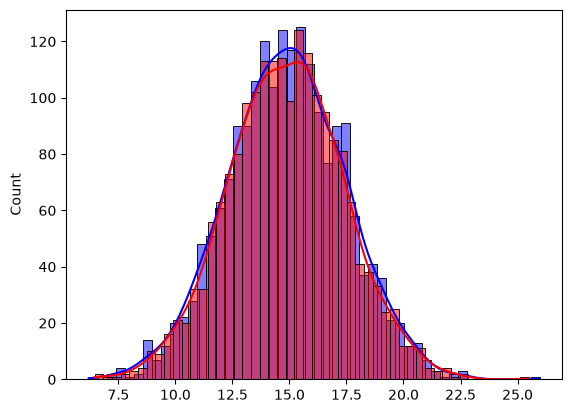

In [133]:
# Plot
sns.histplot(y_test, bins=50, color='blue', alpha=0.5, label='Actual', kde=True)
sns.histplot(y_pred, bins=50, color='red', alpha=0.5, label='Predicted', kde=True)